# 01 Text Preprocessing

## 📚 Learning Objectives

By completing this notebook, you will:
- Clean and normalize text (lowercasing, punctuation, whitespace)
- Use basic preprocessing pipelines for NLP
- Prepare text for downstream tasks

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 2, lesson 08 "Feature Extraction from Unstructured Data" — cleaning is still the first step; here the messy column is language rather than numbers.

**Used later in:** Course 07 — Unit 2, which tokenises the normalised text, and Unit 3, which turns it into TF-IDF features.

---


## 🌍 Why this matters: the town that could not sign up for email

In 1996 AOL put a profanity filter on its sign-up form. The filter matched offensive strings *anywhere
inside* a word, so residents of **Scunthorpe** — a real town in North Lincolnshire, England — could not
create an account: the town's name contains a four-letter obscenity as a substring, and the address field
was mandatory. Users in Penistone, Clitheroe and Lightwater hit the same wall. AOL's stop-gap was to store
the town as "Sconthope". The bug is famous enough to have a name — the **Scunthorpe problem** — and it
still resurfaces in new content filters every few years.

**What goes wrong without this lesson.** Nobody at AOL decided to block a town. Somebody wrote one line of
text processing — *match this string, lowercase, no word boundaries* — and shipped it. Every preprocessing
choice you make below (lowercase? strip punctuation? drop stop words?) is a decision of exactly that kind:
invisible in the code, loud in production. The purpose of this notebook is to make you look at what each
step does to the text **before** you trust it.

**The same failure in other domains:** clinical NLP needs a dedicated negation algorithm — NegEx (Chapman
et al., *J. Biomedical Informatics* 34(5), 2001) and its 35 negation phrases — precisely because a generic
pipeline that drops "no" and "not" as stop words turns *"no evidence of tumour"* into *"evidence of
tumour"*; a bank's transaction cleaner that strips Arabic diacritics can merge two different customers into
one; a résumé parser that lowercases everything cannot tell the profession "IT" from the pronoun "it".

## 📥 Inputs & 📤 Outputs

**Inputs:** a short 3-sentence paragraph about NLP, defined directly in the code cell (no downloads), plus Python's `re`, `string`, `collections.Counter`, and Matplotlib.

**Outputs:** the token list, the punctuation-free text, the tokens after stop-word removal, a word-frequency table, and a bar chart of the top frequencies — all computed live from that paragraph.

---

Example 1: Text Preprocessing

Original Text:

Natural Language Processing (NLP) is a branch of artificial intelligence
that helps computers understand, interpret, and manipulate human language.
NLP combines computational linguistics with machine learning.


1. Tokenization

Tokens: ['natural', 'language', 'processing', '(nlp)', 'is', 'a', 'branch', 'of', 'artificial', 'intelligence', 'that', 'helps', 'computers', 'understand,', 'interpret,', 'and', 'manipulate', 'human', 'language.', 'nlp', 'combines', 'computational', 'linguistics', 'with', 'machine', 'learning.']
Number of tokens: 26

2. Remove Punctuation

Cleaned text:

Natural Language Processing NLP is a branch of artificial intelligence
that helps computers understand interpret and manipulate human language
NLP combines computational linguistics with machine learning


3. Stop Word Removal

Tokens after stop word removal: ['natural', 'language', 'processing', '(nlp)', 'branch', 'of', 'artificial', 'intelligence', 'helps', 'comp

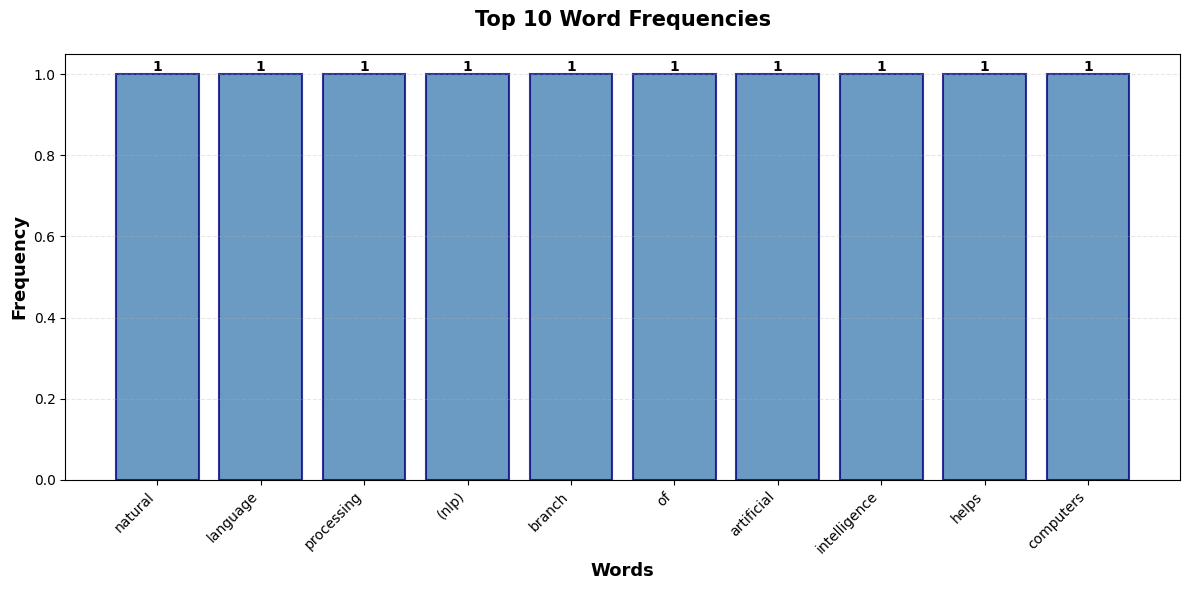


✅ Word frequency visualization displayed!


In [1]:
# Worked example: a complete miniature text-preprocessing pipeline on one paragraph.
# Why it matters: every NLP system starts here — raw text must become clean tokens
# before any model can count, embed, or classify it. Watch each step change the text.

"""
Unit 1 - Example 1: Text Preprocessing

This example demonstrates:
1. Simple whitespace tokenization
2. Punctuation removal (text normalization)
3. Stop word removal
4. Word frequency analysis with a bar chart
"""

import re
import string
from collections import Counter

print("=" * 60)
print("Example 1: Text Preprocessing")
print("=" * 60)

# Sample text
sample_text = """
Natural Language Processing (NLP) is a branch of artificial intelligence
that helps computers understand, interpret, and manipulate human language.
NLP combines computational linguistics with machine learning.
"""

print("\nOriginal Text:")
print(sample_text)

# 1. Tokenization
print("\n" + "=" * 60)
print("1. Tokenization")
print("=" * 60)

def simple_tokenize(text):
    """
    Simple tokenization by splitting on whitespace.
    """
    # Remove extra whitespace and split
    tokens = text.lower().split()
    return tokens

tokens = simple_tokenize(sample_text)
print(f"\nTokens: {tokens}")
print(f"Number of tokens: {len(tokens)}")

# 2. Remove Punctuation
print("\n" + "=" * 60)
print("2. Remove Punctuation")
print("=" * 60)

def remove_punctuation(text):
    """
    Remove punctuation from text.
    """
    return text.translate(str.maketrans('', '', string.punctuation))

cleaned_text = remove_punctuation(sample_text)
print(f"\nCleaned text:\n{cleaned_text}")

# 3. Stop Word Removal
print("\n" + "=" * 60)
print("3. Stop Word Removal")
print("=" * 60)

# Common English stop words
stop_words = {'is', 'a', 'the', 'that', 'this', 'with', 'and', 'or', 'but'}

def remove_stop_words(tokens, stop_words):
    """
    Remove stop words from tokens.
    """
    return [token for token in tokens if token not in stop_words]

filtered_tokens = remove_stop_words(tokens, stop_words)
print(f"\nTokens after stop word removal: {filtered_tokens}")

# 4. Word Frequency
print("\n" + "=" * 60)
print("4. Word Frequency Analysis")
print("=" * 60)

word_freq = Counter(filtered_tokens)
print("\nWord Frequencies:")
for word, freq in word_freq.most_common():
    print(f"  {word}: {freq}")

print("\n" + "=" * 60)
print("Example completed successfully!")
print("=" * 60)

# Visualize word frequencies
try:
    import matplotlib.pyplot as plt
    
    if 'word_freq' in locals() and word_freq:
        # Get top 10 most frequent words
        top_words = word_freq.most_common(10) if hasattr(word_freq, 'most_common') else list(word_freq.items())[:10]
        words = [w[0] if isinstance(w, tuple) else w for w in top_words]
        freqs = [w[1] if isinstance(w, tuple) else word_freq[w] for w in top_words]
        
        plt.figure(figsize=(12, 6))
        bars = plt.bar(words, freqs, color='steelblue', alpha=0.8, edgecolor='navy', linewidth=1.5)
        plt.xlabel('Words', fontsize=13, fontweight='bold')
        plt.ylabel('Frequency', fontsize=13, fontweight='bold')
        plt.title('Top 10 Word Frequencies', fontsize=15, pad=20, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add value labels on bars
        for bar, freq in zip(bars, freqs):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{freq}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        print("\n✅ Word frequency visualization displayed!")
    else:
        print("\n⚠️  Word frequency data not available for visualization")
except ImportError:
    print("\n📦 To see word frequency visualization, install:")
    print("   pip install matplotlib")

## 💬 Discuss

Argue these from the output above, not from general principles.

1. The frequency table gives every word a count of 1, and `language` and `language.` were counted as two
   different words. Now imagine this pipeline feeding a search box on a Saudi government portal. Which is
   the more expensive failure — the split counts, or a stop-word list that quietly deletes the one word a
   citizen actually searched for? Defend your choice using the printed output.
2. Our stop-word set is nine hand-picked English words. Name two words you would **add** for this paragraph
   and two you would **refuse** to remove no matter what any list says. What rule are you actually using?
3. `str.translate` deleted every punctuation mark in the text. Name one document type where that is
   destructive — think prices, dates, IBANs, phone numbers, hashtags, Arabic diacritics. Would you rather
   over-clean and lose information, or under-clean and let noise into the model? Who pays for each mistake,
   and would they ever find out?

---

## ✅ Summary

**What you actually did here** (check each claim against the printed output above):

- Tokenized the paragraph by whitespace into 26 lowercase tokens
- Removed punctuation with `str.translate`, and filtered a small hardcoded stop-word set
- Counted word frequencies with `Counter` and plotted the top 10 as a bar chart

**Read the output critically — it teaches the next lesson:** every frequency in this run is 1, and the
naive whitespace tokenizer left `(nlp)` and `language.` as tokens separate from `nlp` and `language`,
splitting their counts. Proper tokenization (Unit 2) fixes exactly this.

**Next steps:**
- Complete `exercises/01_text_preprocessing_exercise.ipynb`
- Proceed to Unit 2 for real tokenization and morphology

## ⚠️ Where this breaks

Everything above rests on one assumption: **meaning survives normalization.** Often it does not.

| Step | Breaks when | Cheaper / safer alternative |
|---|---|---|
| Lowercasing | case carries meaning: `US` vs `us`, `Apple` vs `apple`, `IT` vs `it` | lowercase only for the counting step and keep the original text for display and for NER |
| Punctuation stripping | numbers, prices, dates, URLs, IBANs, hashtags, source code | tokenize first with a type-aware tokenizer, then decide per token type |
| Stop-word removal | short queries and phrases built entirely out of common words | do not use a stop list at all — see below |
| Whitespace tokenization | languages that do not delimit words with spaces (Chinese, Thai), and Arabic clitics (`و`, `ال`, `ب`, `ل`) glued to the next word | subword tokenization — Unit 2 |

**On stop words specifically.** Manning, Raghavan & Schütze's *Introduction to Information Retrieval*
(2008, §2.2.2, <https://nlp.stanford.edu/IR-book/>) points out that queries such as *"President of the
United States"* and *"flights to London"* lose their meaning once the function words are dropped, and
states plainly that **web search engines generally do not use stop lists** — compression and term weighting
handle common words better than deletion ever did. The `stop_words` set here is a teaching device, not a
production default.

**When this is the wrong lesson entirely.** In 2026 much of what arrives as "raw text" is not text: it is
scanned PDFs, invoices and forms, where the hard problems are reading order and table structure, not
punctuation. Those are now handled by small vision-language document parsers such as SmolDocling
([arXiv:2503.11576](https://arxiv.org/abs/2503.11576)) and MinerU2.5
([arXiv:2509.22186](https://arxiv.org/abs/2509.22186)). Regex cleaning is step two of that pipeline, not
step one.

## 📚 References

Where these ideas come from — seminal work first, then a modern survey:

1. Porter, M. F. (1980). *An Algorithm for Suffix Stripping*. Program, 14(3), 130-137.
2. Jurafsky, D. & Martin, J. H. (2025). *Speech and Language Processing* (3rd ed. draft) — chapter on text normalization, tokenization, and edit distance. <https://web.stanford.edu/~jurafsky/slp3/>
3. Mielke, S. J., Alyafeai, Z., Salesky, E., et al. (2021). *Between Words and Characters: A Brief History of Open-Vocabulary Modeling and Tokenization in NLP*. [arXiv:2112.10508](https://arxiv.org/abs/2112.10508)
